# HOUSE PRICES - ADVANCED REGRESSION TECHNIQUES

## 2. Data Understanding
Phần này thực hiện khám phá và tìm hiểu dữ liệu (EDA), bao gồm kiểm tra cấu trúc dữ liệu, kiểu dữ liệu, dữ liệu thiếu, phân phối của biến mục tiêu SalePrice và mối tương quan giữa các đặc trưng.

In [2]:
# CELL 1: IMPORT THƯ VIỆN

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Import thư viện thành công!")

Import thư viện thành công!


In [3]:
# CELL 2: LOAD DATA

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

Train Shape: (1460, 81)
Test Shape: (1459, 80)


In [4]:
# CELL 3: KIỂM TRA THÔNG TIN TẬP TRAIN

train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [5]:
# CELL 4: KIỂM TRA THÔNG TIN TẬP TEST

test.info()

<class 'pandas.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   str    
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   str    
 6   Alley          107 non-null    str    
 7   LotShape       1459 non-null   str    
 8   LandContour    1459 non-null   str    
 9   Utilities      1457 non-null   str    
 10  LotConfig      1459 non-null   str    
 11  LandSlope      1459 non-null   str    
 12  Neighborhood   1459 non-null   str    
 13  Condition1     1459 non-null   str    
 14  Condition2     1459 non-null   str    
 15  BldgType       1459 non-null   str    
 16  HouseStyle     1459 non-null   str    
 17  OverallQual    1459 non-null   int64  
 18  OverallCond    1459

In [6]:
# CELL 5: KIỂM TRA GIÁ TRỊ THIẾU TRONG TRAIN

train.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

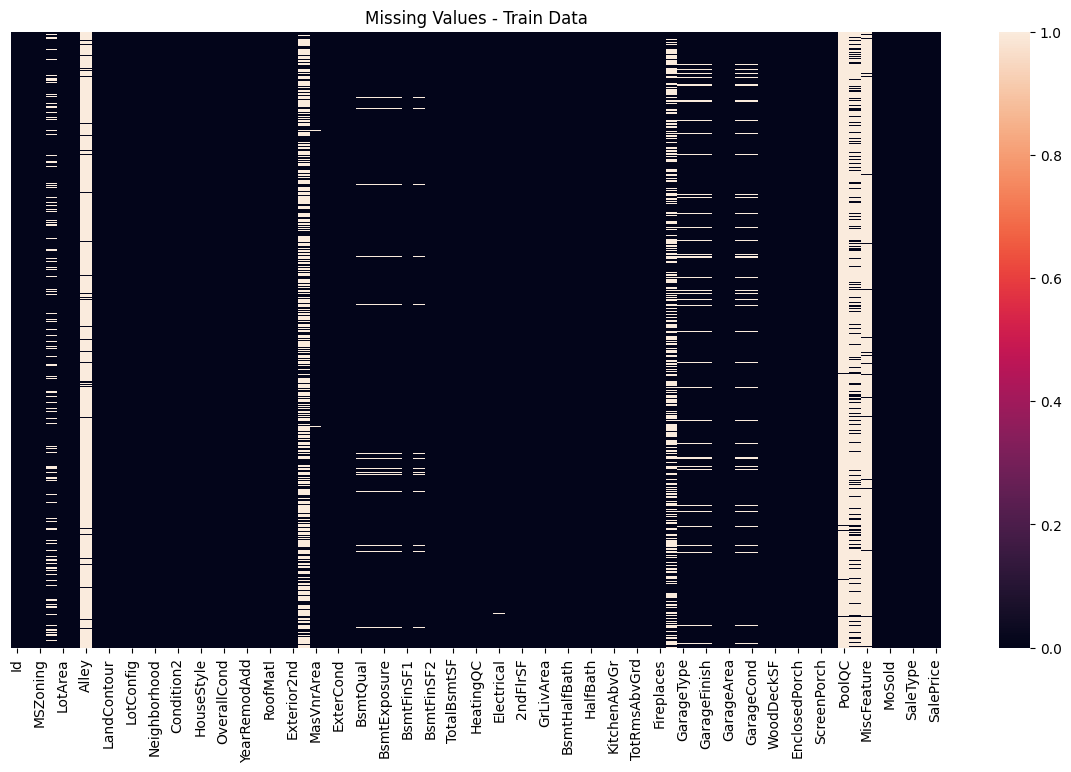

In [7]:
# CELL 6: HEATMAP GIÁ TRỊ THIẾU CỦA TRAIN

plt.figure(figsize=(15, 8))
sns.heatmap(train.isnull(), yticklabels=False, cbar=True)

plt.title("Missing Values - Train Data")
plt.show()

In [8]:
# CELL 7: KIỂM TRA GIÁ TRỊ THIẾU TRONG TEST

test.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64

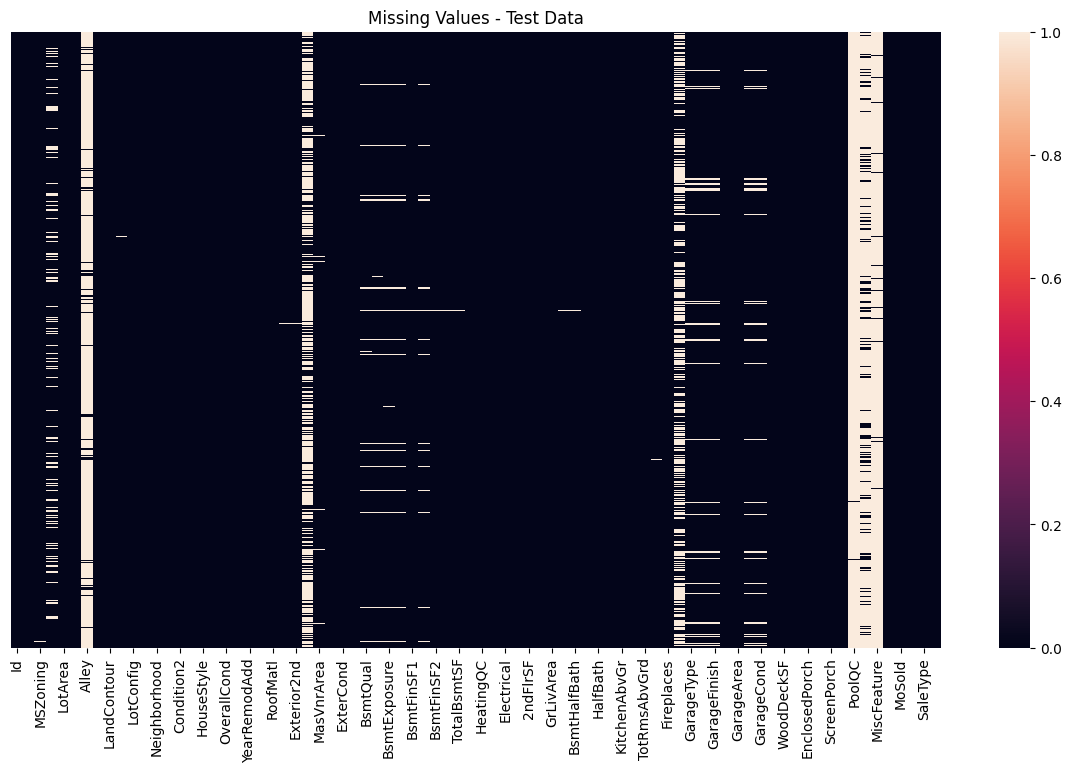

In [9]:
# CELL 8: HEATMAP GIÁ TRỊ THIẾU CỦA TEST

plt.figure(figsize=(15, 8))
sns.heatmap(test.isnull(), yticklabels=False, cbar=True)

plt.title("Missing Values - Test Data")
plt.show()

Biểu đồ phân phối giá nhà

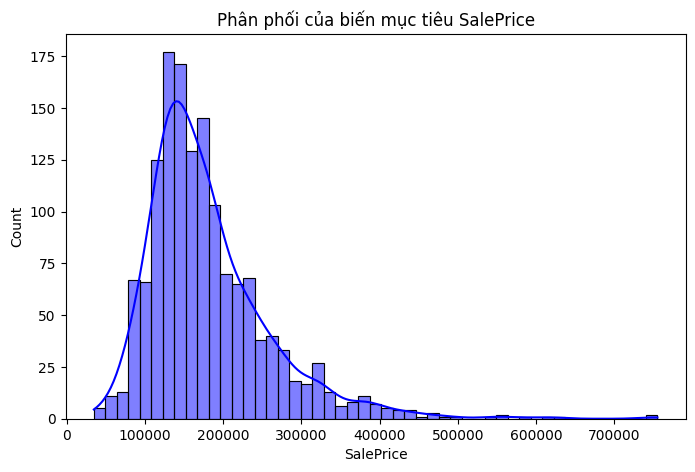

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(train['SalePrice'], kde=True, color='blue')
plt.title("Phân phối của biến mục tiêu SalePrice")
plt.show()

In [11]:
# CELL 9: GỘP DỮ LIỆU ĐỂ TIỀN XỬ LÝ ĐỒNG BỘ

# Tách biến mục tiêu SalePrice ra khỏi tập train
y_train = train['SalePrice']
train_features = train.drop('SalePrice', axis=1)

# Tạo biến cờ 'is_train' để phân biệt sau khi gộp
train_features['is_train'] = 1
test['is_train'] = 0

# Gộp chung train và test lại
df_all = pd.concat([train_features, test], ignore_index=True)
print("Kích thước dữ liệu sau khi gộp:", df_all.shape)

Kích thước dữ liệu sau khi gộp: (2919, 81)


In [12]:
# CELL 10: XỬ LÝ MISSING VALUES - LOẠI BỎ CỘT KHUYẾT > 70%

# Tính ngưỡng dữ liệu không bị khuyết (non-null) tối thiểu là 30%
threshold = len(df_all) * 0.30

# Drop các cột không đạt ngưỡng
df_all = df_all.dropna(thresh=threshold, axis=1)

print("Các cột bị loại bỏ (do khuyết > 70%): Alley, PoolQC, Fence, MiscFeature")
print("Kích thước sau khi drop:", df_all.shape)

Các cột bị loại bỏ (do khuyết > 70%): Alley, PoolQC, Fence, MiscFeature
Kích thước sau khi drop: (2919, 77)


In [13]:
# CELL 11: XỬ LÝ MISSING VALUES - ĐIỀN KHUYẾT (IMPUTATION)

# Tách nhóm cột dạng số (number) và dạng phân loại (object/string)
numeric_cols = df_all.select_dtypes(include=['number']).columns
categorical_cols = df_all.select_dtypes(include=['O']).columns

# Điền Mean (Giá trị trung bình) cho các biến số
for col in numeric_cols:
    df_all[col] = df_all[col].fillna(df_all[col].mean())

# Điền Mode (Giá trị xuất hiện nhiều nhất) cho các biến hạng mục
for col in categorical_cols:
    df_all[col] = df_all[col].fillna(df_all[col].mode()[0])

print("Đã hoàn tất điền Mean cho biến số và Mode cho biến hạng mục.")
print("Kiểm tra lại missing values:", df_all.isnull().sum().sum())

Đã hoàn tất điền Mean cho biến số và Mode cho biến hạng mục.
Kiểm tra lại missing values: 0


C:\Users\Admin\AppData\Local\Temp\ipykernel_12204\3132065245.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_all.select_dtypes(include=['O']).columns


In [14]:
# CELL 12: MÃ HÓA ONE-HOT ENCODING VÀ LỌC TRÙNG LẶP

# Sử dụng pd.get_dummies, drop_first=True giúp giảm đa cộng tuyến
df_all = pd.get_dummies(df_all, columns=categorical_cols, drop_first=True)

# Lọc bỏ các cột trùng lặp (nếu có) do quá trình mã hóa gây ra
df_all = df_all.loc[:, ~df_all.columns.duplicated()]

print("Kích thước sau khi One-Hot Encoding:", df_all.shape)

Kích thước sau khi One-Hot Encoding: (2919, 237)


In [15]:
# CELL 13: TÁCH LẠI TẬP TRAIN & TEST VÀ LƯU DỮ LIỆU SẠCH

# Tách ra dựa trên biến cờ 'is_train', đồng thời drop cột 'Id' vì không có ý nghĩa dự đoán
X_train = df_all[df_all['is_train'] == 1].drop(['is_train', 'Id'], axis=1)
X_test = df_all[df_all['is_train'] == 0].drop(['is_train', 'Id'], axis=1)

# Xuất ra file csv để dùng cho phần Model (tùy chọn)
X_train.to_csv('X_train_clean.csv', index=False)
y_train.to_csv('y_train_clean.csv', index=False)
X_test.to_csv('X_test_clean.csv', index=False)

print("Hoàn tất Data Preparation!")
print("Kích thước X_train cuối cùng:", X_train.shape)
print("Kích thước y_train cuối cùng:", y_train.shape)
print("Kích thước X_test cuối cùng:", X_test.shape)

Hoàn tất Data Preparation!
Kích thước X_train cuối cùng: (1460, 235)
Kích thước y_train cuối cùng: (1460,)
Kích thước X_test cuối cùng: (1459, 235)
